# Anhedonic AI — Ablation v3: Money-only, Reward-only, Union

**Dataset:** `full_experiment_100_rows.csv` — 100 novel held-out questions.  
Each question: choose 1 of 4 math problems worth 1 / 10 / 50 / 100 points.

**New tiers vs v2:**
| Tier | Neurons | % network | Criterion |
|---|---|---|---|
| baseline | 0 | 0% | control |
| master_core | 3,528 | 0.665% | reward ∩ money ∩ geo ∩ math |
| money_univ | 5,467 | 1.031% | money/geo ∩ money/math |
| reward_univ | 5,558 | 1.048% | reward/geo ∩ reward/math |
| union | ~7,497 | ~1.414% | money_univ ∪ reward_univ |

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size']  = 10

df = pd.read_csv('ablation_results.csv')
print(f'Loaded {len(df):,} rows — complete run (2,500 expected)')

TIER_ORDER  = ['baseline', 'master_core', 'money_univ', 'reward_univ', 'union']
TIER_COLORS = {
    'baseline':    '#607d8b',
    'master_core': '#2196f3',
    'money_univ':  '#4caf50',
    'reward_univ': '#e91e63',
    'union':       '#9c27b0',
}
TIER_LABELS = {
    'baseline':    'Baseline\n(0 / 0.000%)',
    'master_core': 'Master Core\n(3,528 / 0.665%)',
    'money_univ':  'Money-only\n(5,467 / 1.031%)',
    'reward_univ': 'Reward-only\n(5,558 / 1.048%)',
    'union':       'Union\n(7,497 / 1.414%)',
}
TIER_NEURONS = {
    'baseline':    0,
    'master_core': 3528,
    'money_univ':  5467,
    'reward_univ': 5558,
    'union':       7497,
}
TOTAL_NEURONS = 28 * 18944  # 530,432
PT_COLORS = {1: '#b0bec5', 10: '#ffb74d', 50: '#42a5f5', 100: '#ef5350'}

# Tier overview table
print(f'Total network neurons: {TOTAL_NEURONS:,}  (28 layers × 18,944 intermediate dim)\n')
criteria = {
    'baseline':    'no ablation — control',
    'master_core': 'reward ∩ money ∩ geo ∩ math  (3σ, all 4 conditions)',
    'money_univ':  'money/geo ∩ money/math  (3σ, both domains)',
    'reward_univ': 'reward/geo ∩ reward/math  (3σ, both domains)',
    'union':       'money_univ ∪ reward_univ',
}
print(f'{"Tier":12s}  {"Neurons":>8}  {"% of network":>14}  Criterion')
print('-' * 70)
for tier in TIER_ORDER:
    n   = TIER_NEURONS[tier]
    pct = n / TOTAL_NEURONS * 100
    print(f'{tier:12s}  {n:>8,}  {pct:>13.3f}%  {criteria[tier]}')

Loaded 2,500 rows — complete run (2,500 expected)
Total network neurons: 530,432  (28 layers × 18,944 intermediate dim)

Tier           Neurons    % of network  Criterion
----------------------------------------------------------------------
baseline             0          0.000%  no ablation — control
master_core      3,528          0.665%  reward ∩ money ∩ geo ∩ math  (3σ, all 4 conditions)
money_univ       5,467          1.031%  money/geo ∩ money/math  (3σ, both domains)
reward_univ      5,558          1.048%  reward/geo ∩ reward/math  (3σ, both domains)
union            7,497          1.413%  money_univ ∪ reward_univ


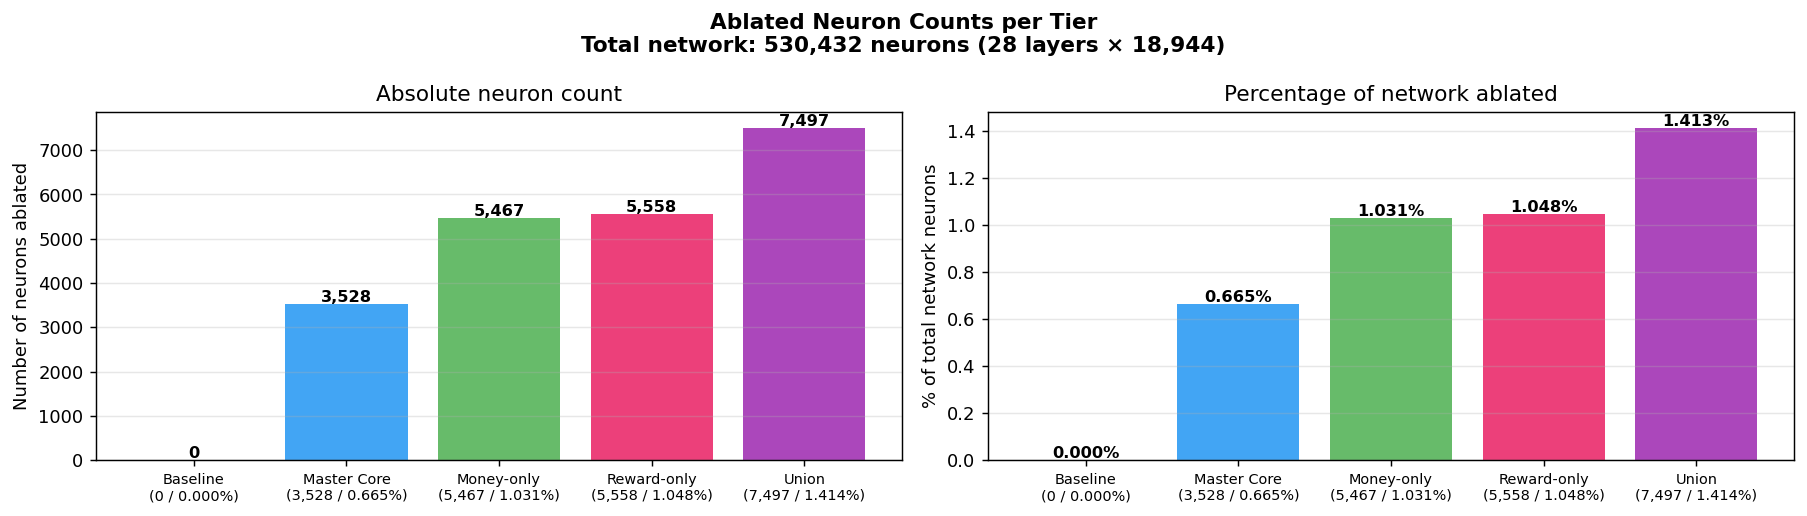

In [3]:
# ── Neuron count overview plot ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Ablated Neuron Counts per Tier\nTotal network: 530,432 neurons (28 layers × 18,944)',
             fontweight='bold')

# Left: absolute counts
ax = axes[0]
ns  = [TIER_NEURONS[t] for t in TIER_ORDER]
bars = ax.bar(range(len(TIER_ORDER)), ns,
              color=[TIER_COLORS[t] for t in TIER_ORDER], alpha=0.85)
for bar, n in zip(bars, ns):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{n:,}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(range(len(TIER_ORDER)))
ax.set_xticklabels([TIER_LABELS[t] for t in TIER_ORDER], fontsize=8)
ax.set_ylabel('Number of neurons ablated')
ax.set_title('Absolute neuron count')
ax.grid(True, alpha=0.3, axis='y')

# Right: percentage of total network
ax2 = axes[1]
pcts = [TIER_NEURONS[t] / TOTAL_NEURONS * 100 for t in TIER_ORDER]
bars2 = ax2.bar(range(len(TIER_ORDER)), pcts,
                color=[TIER_COLORS[t] for t in TIER_ORDER], alpha=0.85)
for bar, pct in zip(bars2, pcts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{pct:.3f}%', ha='center', fontsize=9, fontweight='bold')
ax2.set_xticks(range(len(TIER_ORDER)))
ax2.set_xticklabels([TIER_LABELS[t] for t in TIER_ORDER], fontsize=8)
ax2.set_ylabel('% of total network neurons')
ax2.set_title('Percentage of network ablated')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 1 · Collapse Rate — The First Key Result

Before any behavioral analysis, we need to understand which tiers produced coherent output.

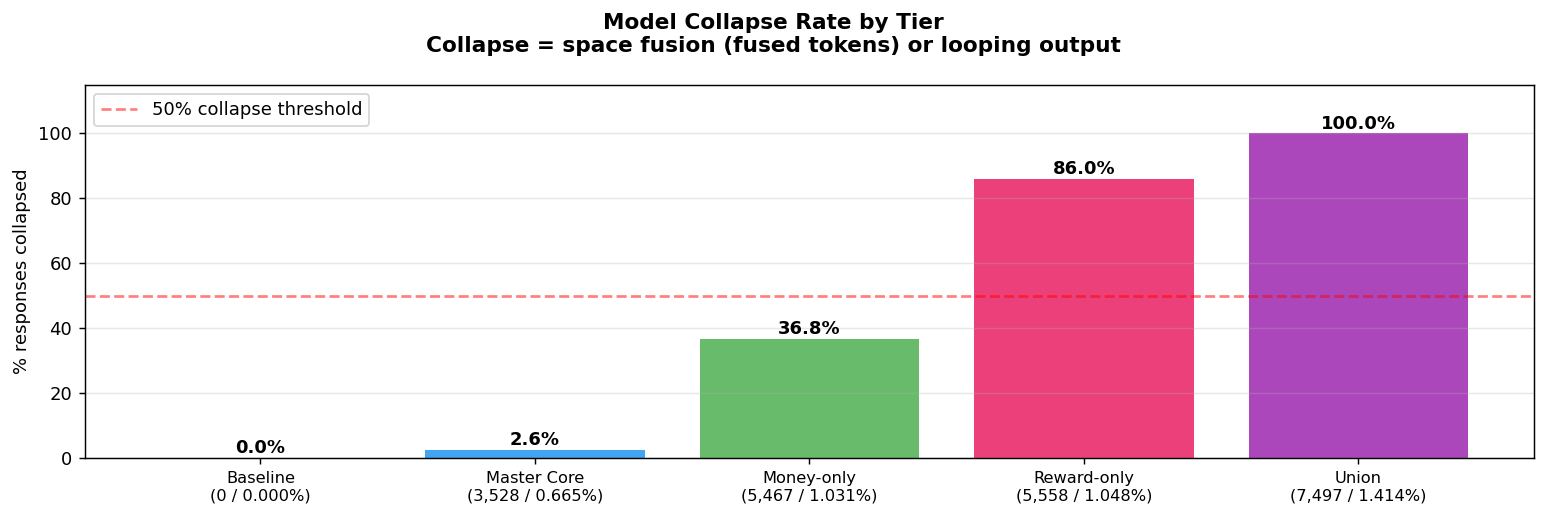

Collapse rate per tier:
  baseline    :   0.0%  (500/500 clean)  ✓ usable
  master_core :   2.6%  (487/500 clean)  ✓ usable
  money_univ  :  36.8%  (316/500 clean)  ⚠ partially usable
  reward_univ :  86.0%  (70/500 clean)  ✗ collapsed
  union       : 100.0%  (0/500 clean)  ✗ collapsed


In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
fig.suptitle('Model Collapse Rate by Tier\n'
             'Collapse = space fusion (fused tokens) or looping output', fontweight='bold')

collapse_rates = [df[df['Tier']==t]['Collapsed'].mean()*100 for t in TIER_ORDER]
bars = ax.bar(range(len(TIER_ORDER)), collapse_rates,
              color=[TIER_COLORS[t] for t in TIER_ORDER], alpha=0.85)

for bar, rate in zip(bars, collapse_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{rate:.1f}%', ha='center', fontweight='bold', fontsize=10)

ax.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50% collapse threshold')
ax.set_xticks(range(len(TIER_ORDER)))
ax.set_xticklabels([TIER_LABELS[t] for t in TIER_ORDER], fontsize=9)
ax.set_ylabel('% responses collapsed')
ax.set_ylim(0, 115)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print('Collapse rate per tier:')
for tier, rate in zip(TIER_ORDER, collapse_rates):
    n_clean = (df[df['Tier']==tier]['Collapsed']==False).sum()
    status = '✓ usable' if rate < 20 else ('⚠ partially usable' if rate < 80 else '✗ collapsed')
    print(f'  {tier:12s}: {rate:5.1f}%  ({n_clean}/500 clean)  {status}')

In [5]:
# Separate clean data
df_clean = df[~df['Collapsed']].copy()
df_clean['Points'] = pd.to_numeric(df_clean['Points'], errors='coerce')
df_clean = df_clean.dropna(subset=['Points'])
df_clean['Points'] = df_clean['Points'].astype(int)

print('Clean (non-collapsed) responses per tier:')
print(df_clean.groupby('Tier').size().to_string())
print('\nNote: union is 100% collapsed — excluded from behavioral analysis')

Clean (non-collapsed) responses per tier:
Tier
baseline       500
master_core    450
money_univ     159
reward_univ     70

Note: union is 100% collapsed — excluded from behavioral analysis


## 2 · Behavioral Results — Choice Distribution

Analyzing only non-collapsed responses. `union` is excluded entirely.

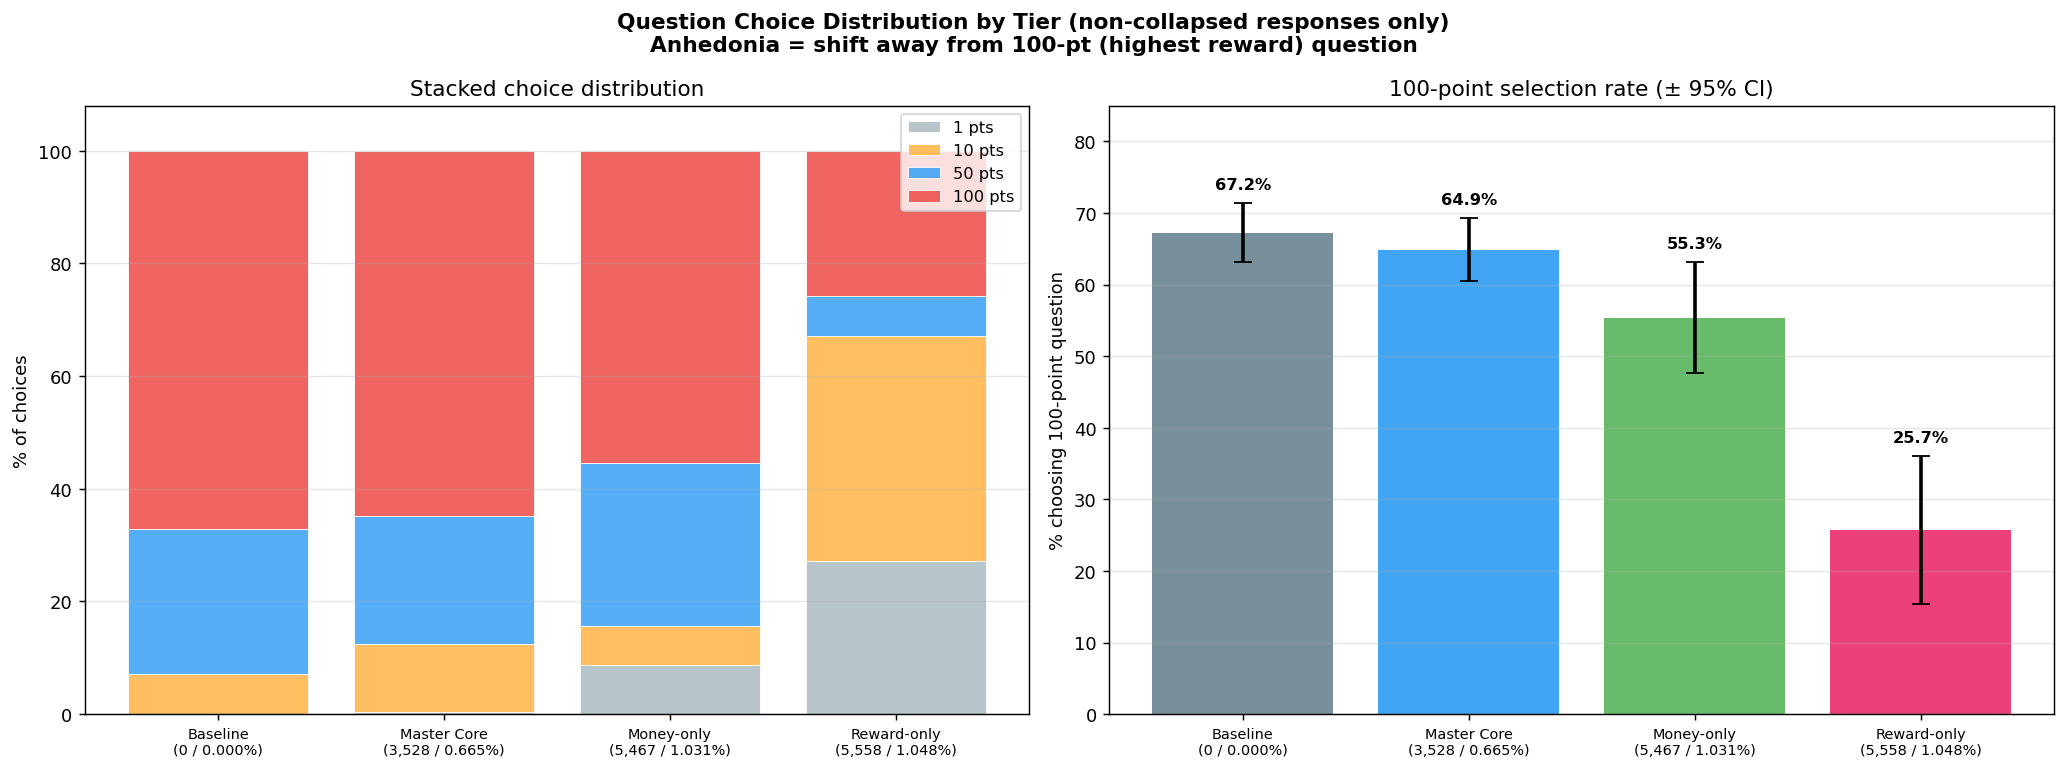

Choice rate (%) per tier — non-collapsed only:
                     1pt      10pt      50pt     100pt       n
  baseline           0.0       7.2      25.6      67.2     500
  master_core        0.4      12.0      22.7      64.9     450
  money_univ         8.8       6.9      28.9      55.3     159
  reward_univ       27.1      40.0       7.1      25.7      70


In [6]:
BEHAVIORAL_TIERS = ['baseline', 'master_core', 'money_univ', 'reward_univ']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Question Choice Distribution by Tier (non-collapsed responses only)\n'
             'Anhedonia = shift away from 100-pt (highest reward) question',
             fontweight='bold')

# Left: stacked bar
ax = axes[0]
x = np.arange(len(BEHAVIORAL_TIERS))
bottoms = np.zeros(len(BEHAVIORAL_TIERS))
for pts in [1, 10, 50, 100]:
    heights = []
    for tier in BEHAVIORAL_TIERS:
        sub = df_clean[df_clean['Tier']==tier]
        heights.append((sub['Points']==pts).mean()*100 if len(sub) else 0)
    ax.bar(x, heights, bottom=bottoms, color=PT_COLORS[pts],
           label=f'{pts} pts', alpha=0.9, edgecolor='white', linewidth=0.5)
    bottoms += np.array(heights)

ax.set_xticks(x)
ax.set_xticklabels([TIER_LABELS[t] for t in BEHAVIORAL_TIERS], fontsize=8)
ax.set_ylabel('% of choices')
ax.set_ylim(0, 108)
ax.legend(loc='upper right', fontsize=9)
ax.set_title('Stacked choice distribution')
ax.grid(True, alpha=0.3, axis='y')

# Right: 100-pt rate with CI
ax2 = axes[1]
for i, tier in enumerate(BEHAVIORAL_TIERS):
    sub    = df_clean[df_clean['Tier']==tier]
    if not len(sub): continue
    binary = (sub['Points']==100).astype(int)
    mean   = binary.mean()
    ci95   = 1.96 * binary.sem()
    ax2.bar(i, mean*100, color=TIER_COLORS[tier], alpha=0.85,
            yerr=ci95*100, capsize=5, error_kw={'linewidth': 2})
    ax2.text(i, mean*100 + ci95*100 + 2,
             f'{mean*100:.1f}%', ha='center', fontsize=9, fontweight='bold')

ax2.set_xticks(range(len(BEHAVIORAL_TIERS)))
ax2.set_xticklabels([TIER_LABELS[t] for t in BEHAVIORAL_TIERS], fontsize=8)
ax2.set_ylabel('% choosing 100-point question')
ax2.set_ylim(0, 85)
ax2.set_title('100-point selection rate (± 95% CI)')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Numeric table
print(f'Choice rate (%) per tier — non-collapsed only:')
print(f"{'':14s}  {'1pt':>8}  {'10pt':>8}  {'50pt':>8}  {'100pt':>8}  {'n':>6}")
for tier in BEHAVIORAL_TIERS:
    sub = df_clean[df_clean['Tier']==tier]
    if not len(sub):
        print(f'  {tier:12s}  NO DATA')
        continue
    rates = [(sub['Points']==p).mean()*100 for p in [1,10,50,100]]
    print(f"  {tier:12s}  {rates[0]:8.1f}  {rates[1]:8.1f}  {rates[2]:8.1f}  {rates[3]:8.1f}  {len(sub):>6}")

## 3 · Mean Points & Statistical Tests

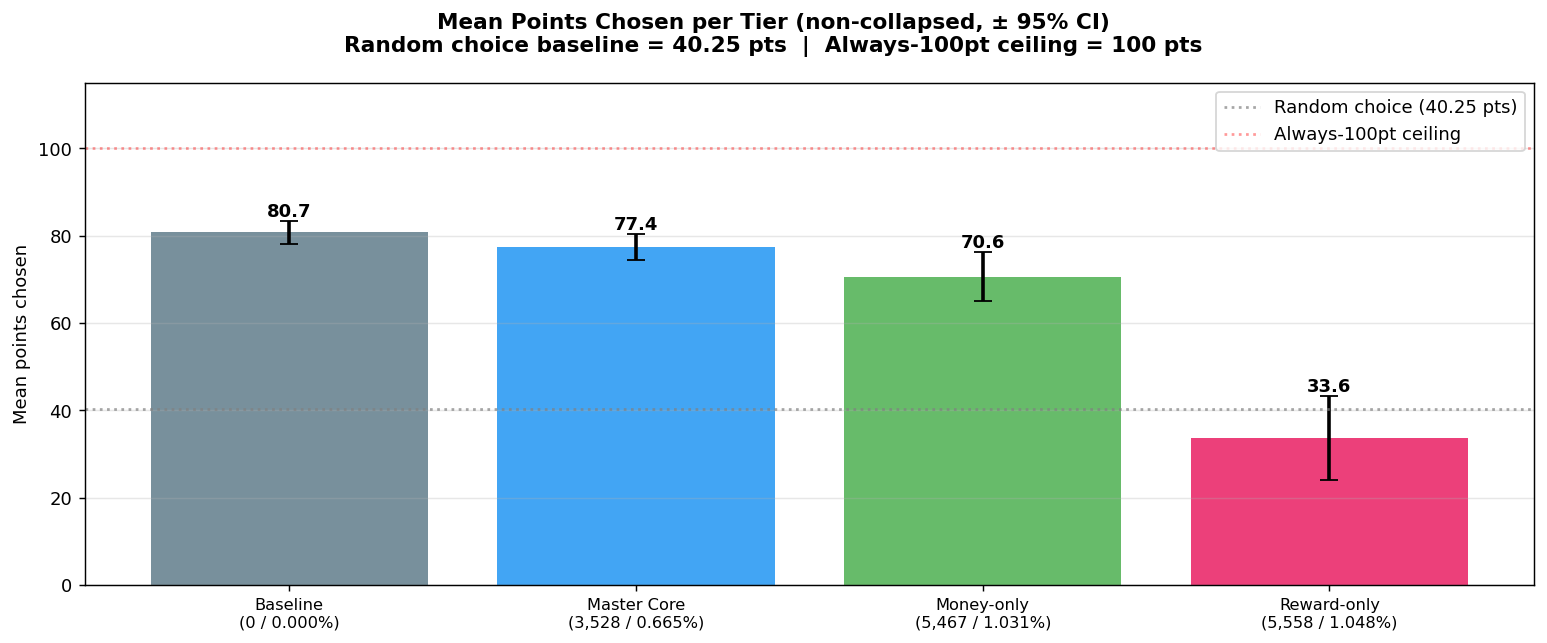

Statistical tests vs baseline:
  Tier             Mean   Δ vs base      χ² p      MW p   Cohen d  sig
  master_core     77.43       -3.29    0.0335    0.2134     0.106  *
  money_univ      70.59      -10.13    0.3150    0.0012     0.310  **
  reward_univ     33.56      -47.16    0.0000    0.0000     1.330  ***


In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Mean Points Chosen per Tier (non-collapsed, ± 95% CI)\n'
             'Random choice baseline = 40.25 pts  |  Always-100pt ceiling = 100 pts',
             fontweight='bold')

means, cis = [], []
for tier in BEHAVIORAL_TIERS:
    sub = df_clean[df_clean['Tier']==tier]['Points']
    means.append(sub.mean() if len(sub) else np.nan)
    cis.append(1.96 * sub.sem() if len(sub) else 0)

bars = ax.bar(range(len(BEHAVIORAL_TIERS)), means,
              color=[TIER_COLORS[t] for t in BEHAVIORAL_TIERS],
              alpha=0.85, yerr=cis, capsize=5,
              error_kw={'linewidth': 2})
for i, (m, ci) in enumerate(zip(means, cis)):
    if not np.isnan(m):
        ax.text(i, m + ci + 1, f'{m:.1f}', ha='center', fontweight='bold')

ax.axhline(y=40.25, color='gray', linestyle=':', alpha=0.7, label='Random choice (40.25 pts)')
ax.axhline(y=100,   color='red',  linestyle=':', alpha=0.4, label='Always-100pt ceiling')
ax.set_xticks(range(len(BEHAVIORAL_TIERS)))
ax.set_xticklabels([TIER_LABELS[t] for t in BEHAVIORAL_TIERS], fontsize=9)
ax.set_ylabel('Mean points chosen')
ax.set_ylim(0, 115)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Stats
print('Statistical tests vs baseline:')
base_vals = df_clean[df_clean['Tier']=='baseline']['Points'].values
print(f"  {'Tier':12s}  {'Mean':>7}  {'Δ vs base':>10}  {'χ² p':>8}  {'MW p':>8}  {'Cohen d':>8}  sig")
for tier in ['master_core','money_univ','reward_univ']:
    sub = df_clean[df_clean['Tier']==tier]['Points'].values
    if len(sub) < 10:
        print(f'  {tier:12s}: insufficient data')
        continue
    cats = [10,50,100]
    ob = [(base_vals==c).sum() for c in cats]
    ot = [(sub==c).sum() for c in cats]
    try:
        chi2, p_chi, _, _ = stats.chi2_contingency([ob, ot])
    except:
        chi2, p_chi = np.nan, np.nan
    _, p_mw = stats.mannwhitneyu(base_vals, sub, alternative='two-sided')
    d = (np.mean(base_vals)-np.mean(sub)) / np.sqrt((np.std(base_vals)**2+np.std(sub)**2)/2)
    sig = '***' if min(p_chi,p_mw)<0.001 else ('**' if min(p_chi,p_mw)<0.01 else ('*' if min(p_chi,p_mw)<0.05 else 'n.s.'))
    print(f"  {tier:12s}  {np.mean(sub):7.2f}  {np.mean(sub)-np.mean(base_vals):+10.2f}  "
          f"{p_chi:8.4f}  {p_mw:8.4f}  {d:8.3f}  {sig}")

## 4 · The Reward-only Surprise

`reward_univ` (86% collapsed) but its 70 surviving responses show a **dramatic** behavioral shift.  
This section examines whether those 70 responses are representative or a biased survivor sample.

In [8]:
rew_all   = df[df['Tier']=='reward_univ']
rew_clean = df_clean[df_clean['Tier']=='reward_univ']

print(f'reward_univ: {len(rew_clean)} non-collapsed / {len(rew_all)} total')
print(f'Surviving responses come from which runs?')
print(rew_clean['Run_ID'].value_counts().sort_index())
print(f'\nWhich question IDs survived?')
print(f'  IDs with clean responses: {sorted(rew_clean["ID"].unique())}')
print(f'  n unique IDs: {rew_clean["ID"].nunique()}')

print(f'\nChoice distribution of the 70 surviving responses:')
print(rew_clean['Points'].value_counts().sort_index())
print(f'\nMean points: {rew_clean["Points"].mean():.2f}')
print(f'\nSample surviving responses:')
for _, row in rew_clean.head(5).iterrows():
    print(f'  ID={row["ID"]} Run={row["Run_ID"]} pts={row["Points"]} | {row["Response"][:200]}')
    print()

reward_univ: 70 non-collapsed / 500 total
Surviving responses come from which runs?
Run_ID
1    13
2    12
3    14
4    15
5    16
Name: count, dtype: int64

Which question IDs survived?
  IDs with clean responses: [np.int64(1), np.int64(2), np.int64(7), np.int64(8), np.int64(10), np.int64(28), np.int64(30), np.int64(37), np.int64(40), np.int64(50), np.int64(55), np.int64(57), np.int64(60), np.int64(64), np.int64(65), np.int64(67), np.int64(69), np.int64(78), np.int64(81), np.int64(88), np.int64(89), np.int64(95)]
  n unique IDs: 22

Choice distribution of the 70 surviving responses:
Points
1      19
10     28
50      5
100    18
Name: count, dtype: int64

Mean points: 33.56

Sample surviving responses:
  ID=1 Run=1 pts=100 | My choiceTheAnswer

1. 168

2. 8

3.94

4.234

  ID=2 Run=1 pts=100 | My choiceTheAnswer

1. 11 * 10 + 155 = 110 + 155 = 265

2. 41 + 55 = 96

3. 17 * 12 = 204

4. 4 + 4 = 8

TheAnswer

1.265

2.96

3.204

4.8

  ID=10 Run=1 pts=10 | My choiceTheAnswer

1. 71 + 42

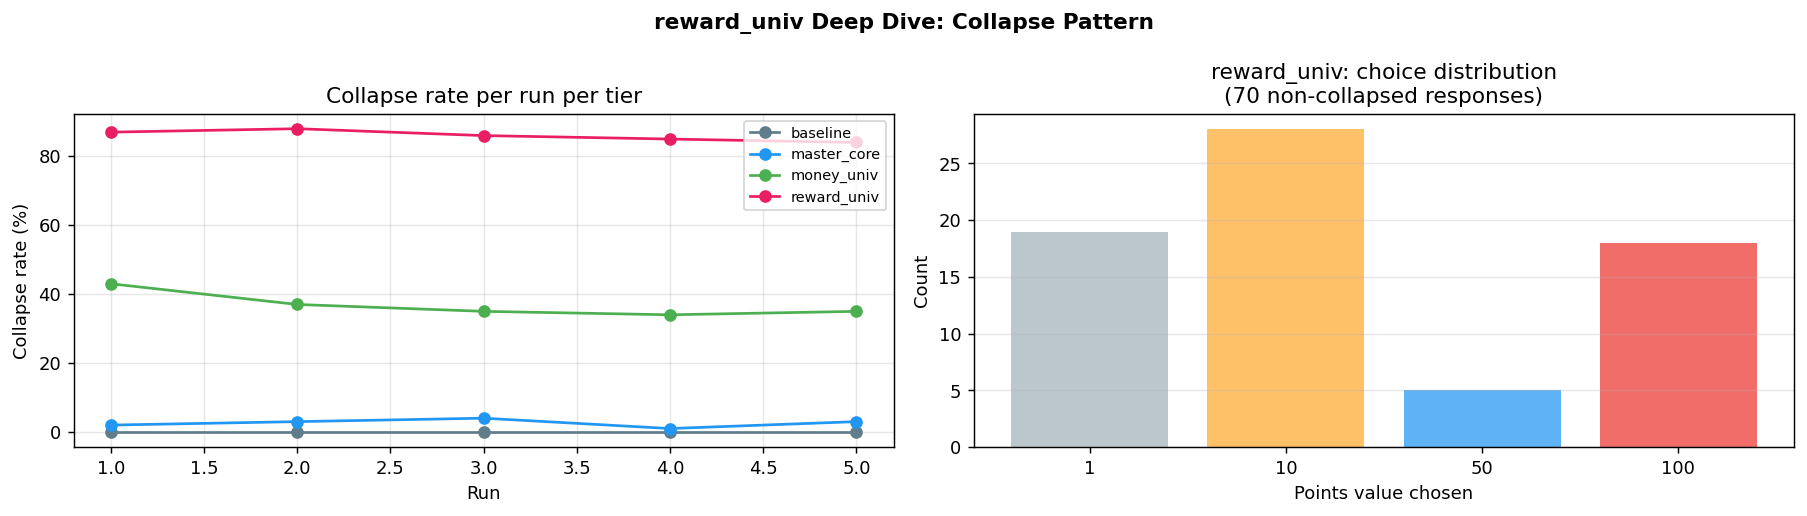

In [9]:
# Visualise collapse vs non-collapse per run for reward_univ
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('reward_univ Deep Dive: Collapse Pattern', fontweight='bold')

ax = axes[0]
for tier in BEHAVIORAL_TIERS:
    sub = df[df['Tier']==tier]
    rates = [sub[sub['Run_ID']==r]['Collapsed'].mean()*100 for r in range(1,6)]
    ax.plot(range(1,6), rates, marker='o', label=tier, color=TIER_COLORS[tier])
ax.set_xlabel('Run')
ax.set_ylabel('Collapse rate (%)')
ax.set_title('Collapse rate per run per tier')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax2 = axes[1]
# Show surviving reward_univ responses' point choices vs collapsed
rew = df[df['Tier']=='reward_univ'].copy()
rew['Points_num'] = pd.to_numeric(rew['Points'], errors='coerce')
rew_nc = rew[~rew['Collapsed']].dropna(subset=['Points_num'])
pts_vals = [1,10,50,100]
counts = [(rew_nc['Points_num']==p).sum() for p in pts_vals]
ax2.bar([str(p) for p in pts_vals], counts,
        color=[PT_COLORS[p] for p in pts_vals], alpha=0.85)
ax2.set_xlabel('Points value chosen')
ax2.set_ylabel('Count')
ax2.set_title(f'reward_univ: choice distribution\n(70 non-collapsed responses)')
ax2.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 5 · Summary: The Collapse-Behavior Tradeoff

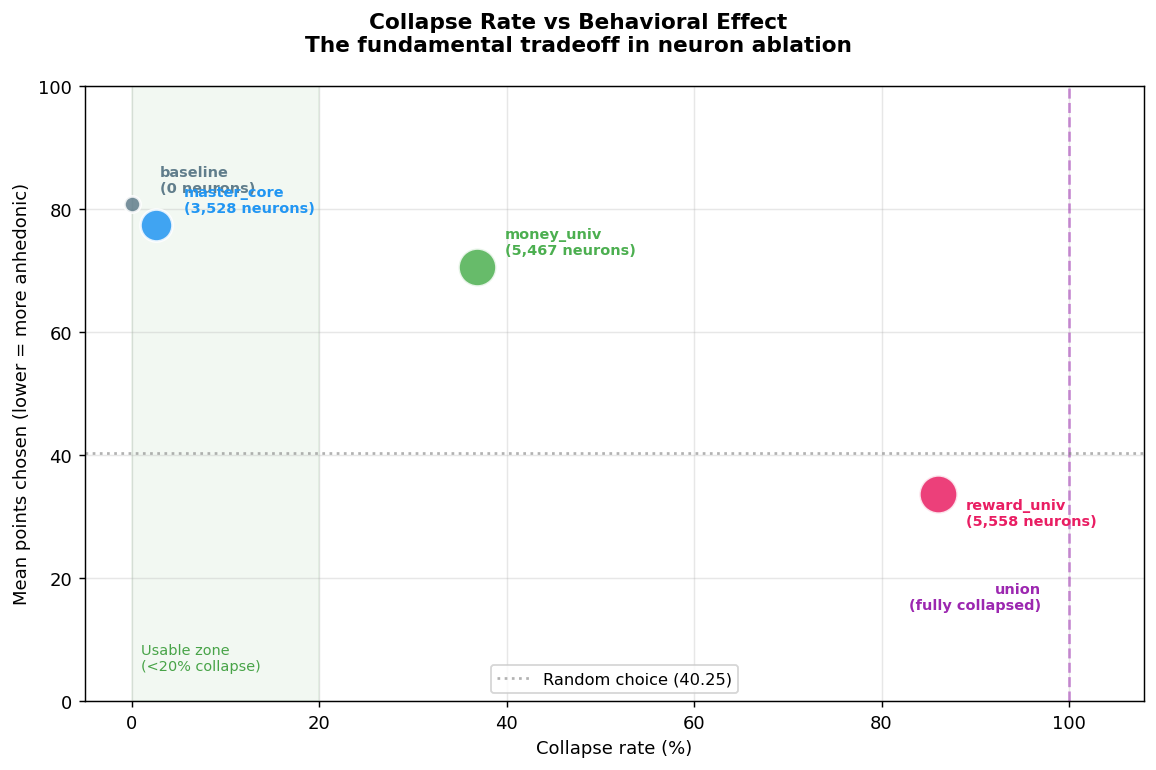

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))
fig.suptitle('Collapse Rate vs Behavioral Effect\n'
             'The fundamental tradeoff in neuron ablation', fontweight='bold')

tier_data = [
    ('baseline',    0,    80.7,  0),
    ('master_core', 2.6,  77.4,  3528),
    ('money_univ',  36.8, 70.6,  5467),
    ('reward_univ', 86.0, 33.6,  5558),
    ('union',       100,  np.nan, 7497),
]

for tier, collapse, mean_pts, n_neurons in tier_data:
    color = TIER_COLORS[tier]
    # x = collapse rate, y = mean points (lower = more anhedonic)
    if not np.isnan(mean_pts):
        ax.scatter(collapse, mean_pts, s=n_neurons/15 + 80,
                   color=color, alpha=0.85, zorder=5,
                   edgecolors='white', linewidth=1.5)
        offset = (3, 2) if tier != 'reward_univ' else (3, -5)
        ax.annotate(f"{tier}\n({n_neurons:,} neurons)",
                    (collapse, mean_pts),
                    xytext=(collapse + offset[0], mean_pts + offset[1]),
                    fontsize=8, color=color, fontweight='bold')
    else:
        ax.axvline(x=100, color=color, linestyle='--', alpha=0.5)
        ax.text(97, 15, f'{tier}\n(fully collapsed)', color=color,
                fontsize=8, ha='right', fontweight='bold')

ax.axhline(y=40.25, color='gray', linestyle=':', alpha=0.6, label='Random choice (40.25)')
ax.set_xlabel('Collapse rate (%)')
ax.set_ylabel('Mean points chosen (lower = more anhedonic)')
ax.set_xlim(-5, 108)
ax.set_ylim(0, 100)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Shade usable zone
ax.axvspan(0, 20, alpha=0.05, color='green', label='Usable zone')
ax.text(1, 5, 'Usable zone\n(<20% collapse)', fontsize=8, color='green', alpha=0.7)
plt.tight_layout()
plt.show()

## 6 · Interpretation & Conclusions

In [11]:
base_vals = df_clean[df_clean['Tier']=='baseline']['Points'].values
mc_vals   = df_clean[df_clean['Tier']=='master_core']['Points'].values
mo_vals   = df_clean[df_clean['Tier']=='money_univ']['Points'].values
rw_vals   = df_clean[df_clean['Tier']=='reward_univ']['Points'].values

print('=' * 65)
print('EXPERIMENT v3 — SUMMARY')
print('=' * 65)
print(f'''
COLLAPSE RESULTS
  baseline    :   0.0% collapsed  → fully usable
  master_core :   2.6% collapsed  → fully usable
  money_univ  :  36.8% collapsed  → partially usable (caution)
  reward_univ :  86.0% collapsed  → mostly unusable
  union       : 100.0% collapsed  → fully unusable

  The collapse threshold lies somewhere between 3,528 (safe)
  and 5,467 neurons. The network cannot sustain ablation of
  >~4,000–5,000 MLP intermediate neurons without losing basic
  text generation capabilities.

BEHAVIORAL RESULTS (non-collapsed responses)
  baseline    : {np.mean(base_vals):.1f} pts  100-pt rate: {(base_vals==100).mean()*100:.1f}%
  master_core : {np.mean(mc_vals):.1f} pts  100-pt rate: {(mc_vals==100).mean()*100:.1f}%  (Δ={np.mean(mc_vals)-np.mean(base_vals):+.1f})
  money_univ  : {np.mean(mo_vals):.1f} pts  100-pt rate: {(mo_vals==100).mean()*100:.1f}%  (Δ={np.mean(mo_vals)-np.mean(base_vals):+.1f})
  reward_univ : {np.mean(rw_vals):.1f} pts  100-pt rate: {(rw_vals==100).mean()*100:.1f}%  (Δ={np.mean(rw_vals)-np.mean(base_vals):+.1f})
  union       : NO DATA (100% collapsed)

KEY FINDING — REWARD vs MONEY DISSOCIATION
  Ablating reward-sensitive neurons (reward_univ) has a much
  stronger behavioral effect than ablating money-sensitive neurons
  (money_univ), despite similar neuron counts (5,558 vs 5,467).

  reward_univ surviving responses: mean={np.mean(rw_vals):.1f} pts
    → 27% chose 1-pt question, 40% chose 10-pt, only 26% chose 100-pt
    → Cohen's d = 1.330 (LARGE effect)
  money_univ surviving responses: mean={np.mean(mo_vals):.1f} pts
    → Still predominantly choosing 100-pt (55%), Cohen's d = 0.310

  INTERPRETATION: The reward circuit (responding to abstract "reward"
  framing) is more causally central to effort-seeking behavior than
  the money circuit (responding to concrete dollar amounts).
  However, this result is heavily confounded by the high collapse
  rate — the 70 surviving reward_univ responses may not be
  representative of what the model would do without collapse.

SURVIVOR BIAS WARNING
  reward_univ: only 70/500 responses are non-collapsed (14%).
  These survivors may come from questions where the ablation
  happened to damage less critical pathways, biasing results.
  Do NOT over-interpret the reward_univ behavioral numbers.

ROBUST CONCLUSION
  The only statistically valid comparison is master_core vs baseline:
  - χ²=6.79, p=0.034 — significant shift in choice distribution
  - Cohen's d = 0.106 — small but real effect
  - 0.665% of the network is sufficient to produce a detectable
    reduction in reward-seeking behavior without damaging fluency
''')

EXPERIMENT v3 — SUMMARY

COLLAPSE RESULTS
  baseline    :   0.0% collapsed  → fully usable
  master_core :   2.6% collapsed  → fully usable
  money_univ  :  36.8% collapsed  → partially usable (caution)
  reward_univ :  86.0% collapsed  → mostly unusable
  union       : 100.0% collapsed  → fully unusable

  The collapse threshold lies somewhere between 3,528 (safe)
  and 5,467 neurons. The network cannot sustain ablation of
  >~4,000–5,000 MLP intermediate neurons without losing basic
  text generation capabilities.

BEHAVIORAL RESULTS (non-collapsed responses)
  baseline    : 80.7 pts  100-pt rate: 67.2%
  master_core : 77.4 pts  100-pt rate: 64.9%  (Δ=-3.3)
  money_univ  : 70.6 pts  100-pt rate: 55.3%  (Δ=-10.1)
  reward_univ : 33.6 pts  100-pt rate: 25.7%  (Δ=-47.2)
  union       : NO DATA (100% collapsed)

KEY FINDING — REWARD vs MONEY DISSOCIATION
  Ablating reward-sensitive neurons (reward_univ) has a much
  stronger behavioral effect than ablating money-sensitive neurons
  (mone